In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

In [2]:
import os

print(os.getcwd())  # shows your current folder
print(os.path.exists("data/zomato.csv"))


c:\Desktop\Cuisine_Classification_app
True


In [3]:
try:
    df = pd.read_csv(
        r"data/zomato.csv",
        encoding="latin1",
        sep=",",
        on_bad_lines="skip",
        engine="python"
    )

    print("✅ File loaded successfully!")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

except Exception as e:
    print("❌ Error:", e)

✅ File loaded successfully!
Shape: (56250, 4160)
Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unna

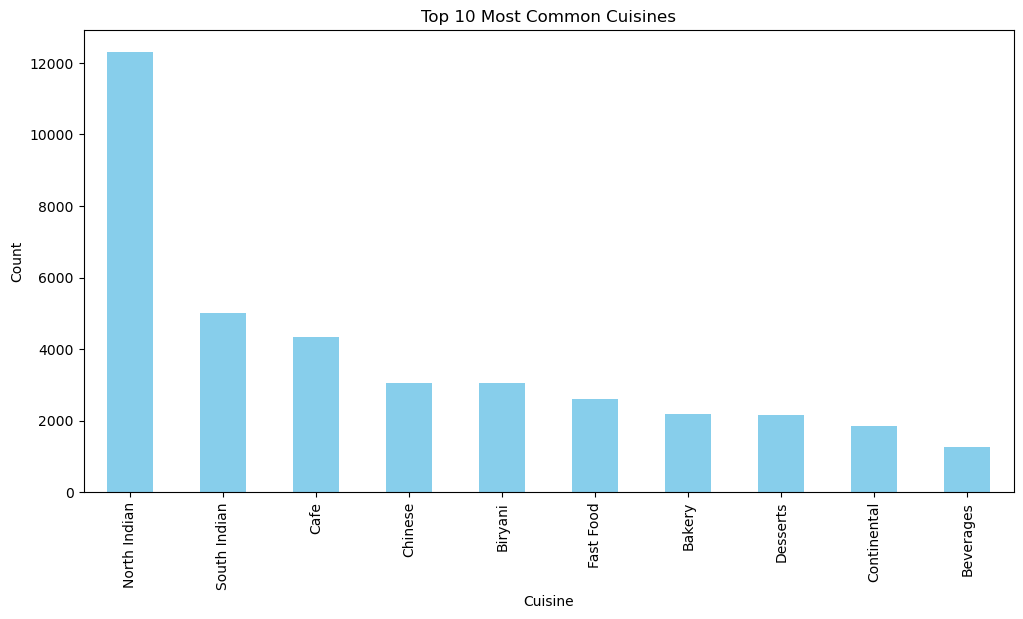

✅ Data cleaned and ready!
Training samples: 44839
Testing samples: 11210


In [4]:
# Drop unneeded columns
df = df.drop(['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item'], axis=1)

# Drop rows where 'cuisines' is missing
df = df.dropna(subset=['cuisines'])

# Fill missing values for other columns
df = df.fillna({
    'rate': '0/5',
    'location': 'Unknown',
    'rest_type': 'Unknown',
    'approx_cost(for two people)': '0'
})

# Clean 'rate' column safely
df['rate'] = df['rate'].astype(str)

# Remove /5
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

# Remove unwanted text
df['rate'] = df['rate'].replace(['NEW', '-', 'nan', 'None'], '0')

# Convert to numeric safely
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Replace invalid values with 0
df['rate'] = df['rate'].fillna(0)

# Clean cost column safely
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

# Remove commas
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Convert safely to numeric
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)

# Replace invalid values with 0
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(0)

# Extract main cuisine (the first one)
df['main_cuisine'] = df['cuisines'].apply(lambda x: str(x).split(',')[0].strip())

# 🔹 Visualize top cuisines
plt.figure(figsize=(12,6))
df['main_cuisine'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.show()

# Encode categorical columns
label = LabelEncoder()
for col in ['online_order', 'book_table', 'location', 'rest_type', 'listed_in(type)', 'listed_in(city)']:
    df[col] = label.fit_transform(df[col])

# Split features and labels
X = df.drop(['cuisines', 'name', 'main_cuisine'], axis=1)
y = df['main_cuisine']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data cleaned and ready!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

In [4]:
import pandas as pd
df = pd.read_csv("data/zomato.csv", encoding="latin1", on_bad_lines="skip", engine="python")

In [10]:
# -----------------------------
# Target variable
# -----------------------------

# Create main cuisine from cuisines column
df['main_cuisine'] = df['cuisines'].astype(str).apply(lambda x: x.split(',')[0].strip())

y = df['main_cuisine']

In [14]:
# -----------------------------
# STEP 0: Clean numeric columns
# -----------------------------

# Clean rate column
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

# Convert votes to numeric
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Fill missing values
df['rate'] = df['rate'].fillna(df['rate'].median())
df['votes'] = df['votes'].fillna(0)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].median()
)

# -----------------------------
# STEP 1: Combine text features
# -----------------------------
if 'dish_liked' in df.columns:
    df['combined_text'] = df['cuisines'].fillna('') + " " + df['dish_liked'].fillna('')
else:
    df['combined_text'] = df['cuisines'].fillna('')

# -----------------------------
# STEP 2: TF-IDF Vectorization
# -----------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

tfidf = TfidfVectorizer(max_features=800)
X_text = tfidf.fit_transform(df['combined_text'])

# -----------------------------
# STEP 3: Encode categorical
# -----------------------------
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

categorical_cols = [
    'online_order',
    'book_table',
    'location',
    'rest_type',
    'listed_in(type)',
    'listed_in(city)'
]

for col in categorical_cols:
    df[col] = label.fit_transform(df[col].astype(str))

# -----------------------------
# STEP 4: Numeric + categorical
# -----------------------------
X_other = df[['online_order','book_table','rate','votes',
              'approx_cost(for two people)','location',
              'rest_type','listed_in(type)','listed_in(city)']]

# Ensure numeric
X_other = X_other.apply(pd.to_numeric, errors='coerce').fillna(0)

# Combine features
X = hstack([csr_matrix(X_other.values), X_text]).tocsr()

y = df['main_cuisine']

# -----------------------------
# STEP 5: Remove rare classes
# -----------------------------
class_counts = y.value_counts()
rare_classes = class_counts[class_counts < 2].index

mask = ~y.isin(rare_classes)

X = X[mask.values]
y = y[mask]

# -----------------------------
# STEP 6: Encode labels
# -----------------------------
label_y = LabelEncoder()
y_encoded = label_y.fit_transform(y)

# -----------------------------
# STEP 7: Train test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# -----------------------------
# STEP 8: Train RandomForest
# -----------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# STEP 9: Evaluation
# -----------------------------
print("✅ XGBoost Model Trained Successfully!")
print("Accuracy:", accuracy_score(y_test, y_pred))

y_test_labels = label_y.inverse_transform(y_test)
y_pred_labels = label_y.inverse_transform(y_pred)

print("\nClassification Report:\n")
print(classification_report(y_test_labels, y_pred_labels))

✅ XGBoost Model Trained Successfully!
Accuracy: 0.9604024969719557

Classification Report:



c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


c:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
import joblib

# Save model and preprocessors
joblib.dump(model, "xgboost_cuisine_model.pkl")
joblib.dump(label_y, "label_encoder.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("✅ Model and preprocessors saved successfully!")


✅ Model and preprocessors saved successfully!
